# 🛒 Olist E-Commerce Analysis
**Dataset:** 96,478 delivered orders | 2016–2018 | Brazilian E-Commerce

---

## Key Findings

### 📈 Revenue
- Revenue grew consistently through 2017, peaking in November 2017 (Black Friday effect)
- Clear seasonal spikes visible around Q4 each year

### 🚚 Delivery Performance
- Average delivery time: **12.0 days**
- Late delivery rate: **7.8%** of all delivered orders
- State of **AL (Alagoas)** has the highest late delivery rate
- Northern/northeastern states consistently slower than São Paulo

### 🛍️ Product Categories
- **Bed, Bath & Table** (`cama_mesa_banho`) is the top revenue category
- Top 3 categories account for a disproportionate share of total revenue

### 💡 Business Recommendations
- Prioritize logistics partnerships in northeastern states to reduce late deliveries
- Invest in inventory for bed/bath/table category ahead of Q4
- Target high-spend states for premium customer acquisition campaigns

   **========================================================================================================**

✅ Step 1: Load and inspect data

💡Idea:

    What data do we have?

    How messy is it?

    What are the relationships?


✔ Why it's important:

    We cannot analyze what we don't understand.

In [ ]:
#All imports

import os
import kaggle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
if not os.path.exists('data/olist_orders_dataset.csv'):
    os.makedirs('data', exist_ok=True)
    print("Downloading dataset from Kaggle...")
    kaggle.api.authenticate()
    kaggle.api.dataset_download_files(
        'olistbr/brazilian-ecommerce',
        path='data/',
        unzip=True
    )
    print("Download complete!")
else:
    print("Data already exists, skipping download.")

In [ ]:
orders = pd.read_csv('data/olist_orders_dataset.csv')
items = pd.read_csv('data/olist_order_items_dataset.csv')
payments = pd.read_csv('data/olist_order_payments_dataset.csv')
customers = pd.read_csv('data/olist_customers_dataset.csv')
products = pd.read_csv('data/olist_products_dataset.csv')

In [2]:
dfs=[
    orders,
    items,
    payments,
    customers,
    products
]

for df in dfs:
    print(df.shape)         # how many rows and columns
    print(df.head())        # first 5 rows
    print(df.info())        # column names, data types, nulls
    print(df.isnull().sum())
    print("\n______________________________________________________END_________________________________________________________________\n")

(99441, 8)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00       

✅ Step 2: Check nulls and structure

💡Idea ; 
Evaluating:

        Missing values

        Wrong types

        Suspicious columns

✔ Why it's important:

    Bad data leads to wrong conclusions.

In [3]:
print("=== ORDERS ===")
print(orders.isnull().sum())
print("\n=== ITEMS ===")
print(items.isnull().sum())
print("\n=== PAYMENTS ===")
print(payments.isnull().sum())
print("\n=== CUSTOMERS ===")
print(customers.isnull().sum())

print("\n_____________________________________________________________\n")

print(orders['order_status'].value_counts())
orders[['order_purchase_timestamp', 
        'order_delivered_customer_date', 
        'order_estimated_delivery_date']].head(10)

=== ORDERS ===
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

=== ITEMS ===
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

=== PAYMENTS ===
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

=== CUSTOMERS ===
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

_____________________________________________________________

order_status
delivered      96478
shipped         1107
can

,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date
0,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00
1,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13 00:00:00
2,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04 00:00:00
3,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15 00:00:00
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26 00:00:00
5,2017-07-09 21:57:05,2017-07-26 10:57:55,2017-08-01 00:00:00
6,2017-04-11 12:22:08,NaN,2017-05-09 00:00:00
7,2017-05-16 13:10:30,2017-05-26 12:55:51,2017-06-07 00:00:00
8,2017-01-23 18:29:09,2017-02-02 14:08:10,2017-03-06 00:00:00
9,2017-07-29 11:55:02,2017-08-16 17:14:30,2017-08-23 00:00:00


✅ Step 3: Filter delivered orders

Idea:
    
    Defining our analysis scope. In this case, the decision was the following: Only completed transactions matter.

✔ Why it's important:
   
    Removes noise (canceled, unavailable orders)

In [4]:
orders_clean = orders[orders['order_status'] == 'delivered'].copy()

print(f"Rows after filter: {len(orders_clean)}")

Rows after filter: 96478


✅ Step 4: Convert to datetime

Idea:
    
    Enable time-based analysis

✔ Why it's important:
    
    Without this we can't:
    
        Compute durations
    
        group by month/year
    
        detect trends




In [5]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders_clean[col] = pd.to_datetime(orders_clean[col])

print("\nNulls after cleaning:")
print(orders_clean.isnull().sum())


Nulls after cleaning:
order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
dtype: int64


✅ Step 5: Merge datasets

Idea:

    Combine separate tables into one analytical view

✔ Why it's important:
 
    We are reconstructing: Everything about an order in one place, one row.

In [6]:
df = orders_clean \
    .merge(items, on='order_id', how='left') \
    .merge(payments, on='order_id', how='left') \
    .merge(customers, on='customer_id', how='left')

print(f"Final dataframe shape: {df.shape}")
print(df.head())

Final dataframe shape: (115038, 22)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
2  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
3  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
4  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp   order_approved_at  \
0    delivered      2017-10-02 10:56:33 2017-10-02 11:07:15   
1    delivered      2017-10-02 10:56:33 2017-10-02 11:07:15   
2    delivered      2017-10-02 10:56:33 2017-10-02 11:07:15   
3    delivered      2018-07-24 20:41:37 2018-07-26 03:24:27   
4    delivered      2018-08-08 08:38:49 2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2017-10

✅ Step 6: Feature engineering

Idea:


    Prepare for 

        trends,

        seasonality,

        grouping,

✔ Why it's important:

    Raw data is hard to analyze.

    We can’t see patterns directly

In [7]:
df['delivery_days'] = (
    df['order_delivered_customer_date'] - 
    df['order_purchase_timestamp']
).dt.days

# Was it delivered late? (1 = late, 0 = on time)
df['is_late'] = (
    df['order_delivered_customer_date'] > 
    df['order_estimated_delivery_date']
).astype(int)

df['purchase_month'] = df['order_purchase_timestamp'].dt.to_period('M')
df['purchase_year'] = df['order_purchase_timestamp'].dt.year

print(df[['delivery_days', 'is_late', 'purchase_month']].head(10))

   delivery_days  is_late purchase_month
0            8.0        0        2017-10
1            8.0        0        2017-10
2            8.0        0        2017-10
3           13.0        0        2018-07
4            9.0        0        2018-08
5           13.0        0        2017-11
6            2.0        0        2018-02
7           16.0        0        2017-07
8            9.0        0        2017-05
9            9.0        0        2017-01


✅ Step 7: Analysis

Idea:

    Answer key business questions using data

    Turn data into insights

✔ Why it's important:

    Data alone has no value

Question 1 — Revenue over time

    Track how revenue changes over time

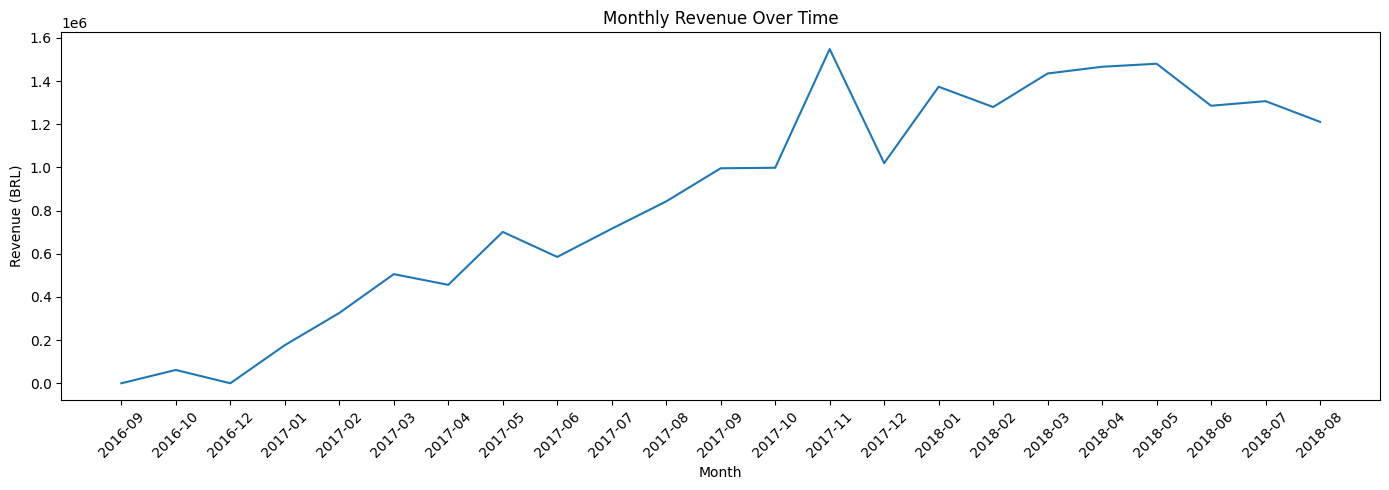

In [ ]:
#import matplotlib.pyplot as plt
#import seaborn as sns             (we already imported them, this is just a reminder.)

# Revenue per month
monthly_revenue = df.groupby('purchase_month')['payment_value'].sum().reset_index()
monthly_revenue['purchase_month'] = monthly_revenue['purchase_month'].astype(str)

plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly_revenue, x='purchase_month', y='payment_value')
plt.xticks(rotation=45)
plt.title('Monthly Revenue Over Time')
plt.xlabel('Month')
plt.ylabel('Revenue (BRL)')
plt.tight_layout()
plt.savefig('charts/monthly_revenue.png', dpi=150)
plt.show()

Question 2 — Top 10 states by revenue

    Find which locations generate the most revenue

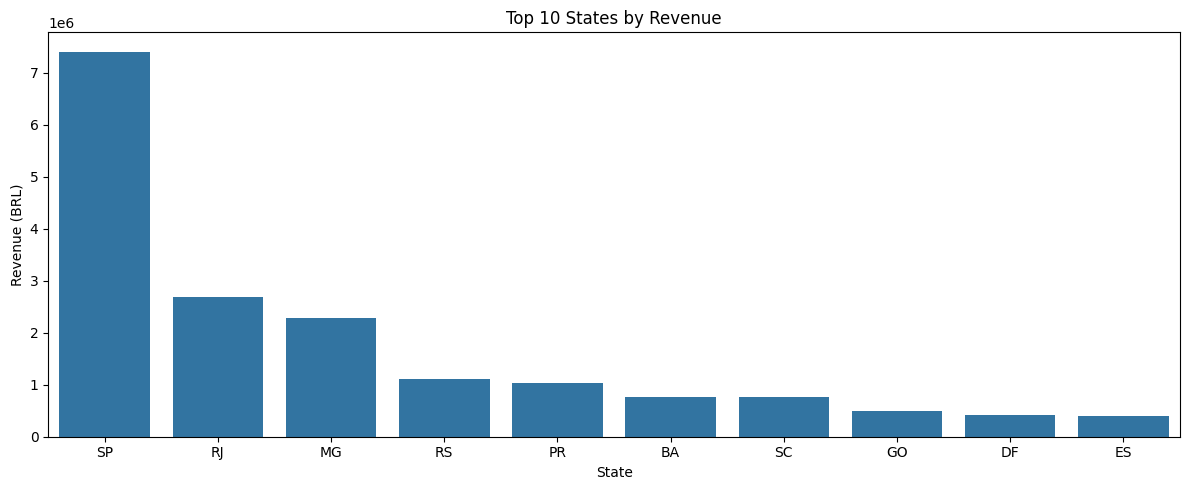

In [9]:
state_revenue = df.groupby('customer_state')['payment_value'] \
                  .sum() \
                  .sort_values(ascending=False) \
                  .head(10) \
                  .reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=state_revenue, x='customer_state', y='payment_value')
plt.title('Top 10 States by Revenue')
plt.xlabel('State')
plt.ylabel('Revenue (BRL)')
plt.tight_layout()
plt.savefig('charts/top_states.png', dpi=150)
plt.show()

Question 3 — Average delivery time and late orders

    Measure delivery speed and late deliveries

Average delivery time: 12.0 days
Late delivery rate: 7.8%


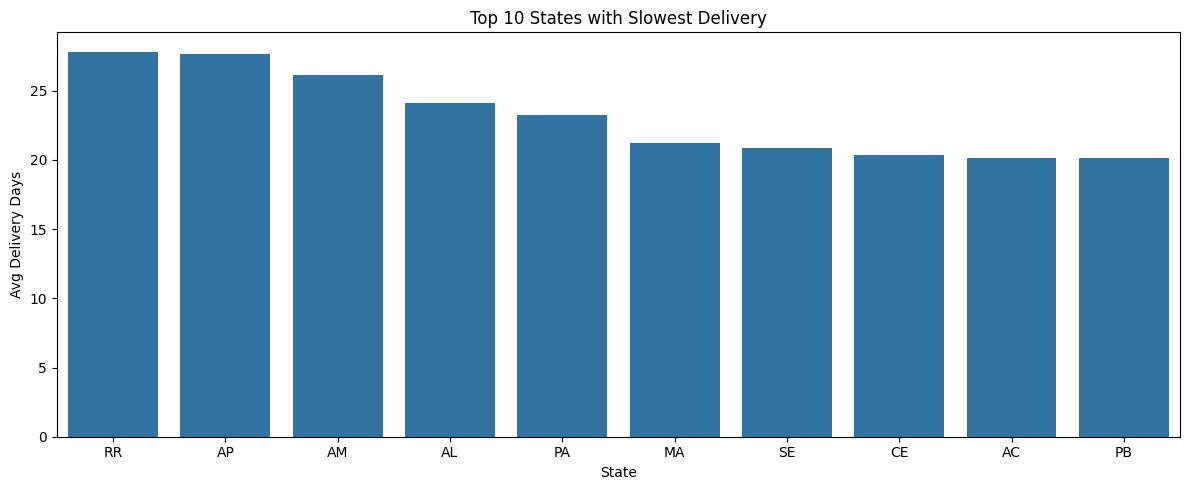

In [10]:
# Overall average delivery time
avg_delivery = df['delivery_days'].mean()
late_rate = df['is_late'].mean() * 100

print(f"Average delivery time: {avg_delivery:.1f} days")
print(f"Late delivery rate: {late_rate:.1f}%")

# Average delivery days by state (top 10 worst)
delivery_by_state = df.groupby('customer_state')['delivery_days'] \
                      .mean() \
                      .sort_values(ascending=False) \
                      .head(10) \
                      .reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=delivery_by_state, x='customer_state', y='delivery_days')
plt.title('Top 10 States with Slowest Delivery')
plt.xlabel('State')
plt.ylabel('Avg Delivery Days')
plt.tight_layout()
plt.savefig('charts/delivery_by_state.png', dpi=150)
plt.show()

Question 4 — Top product categories by revenue

    Identify which products generate the most revenue

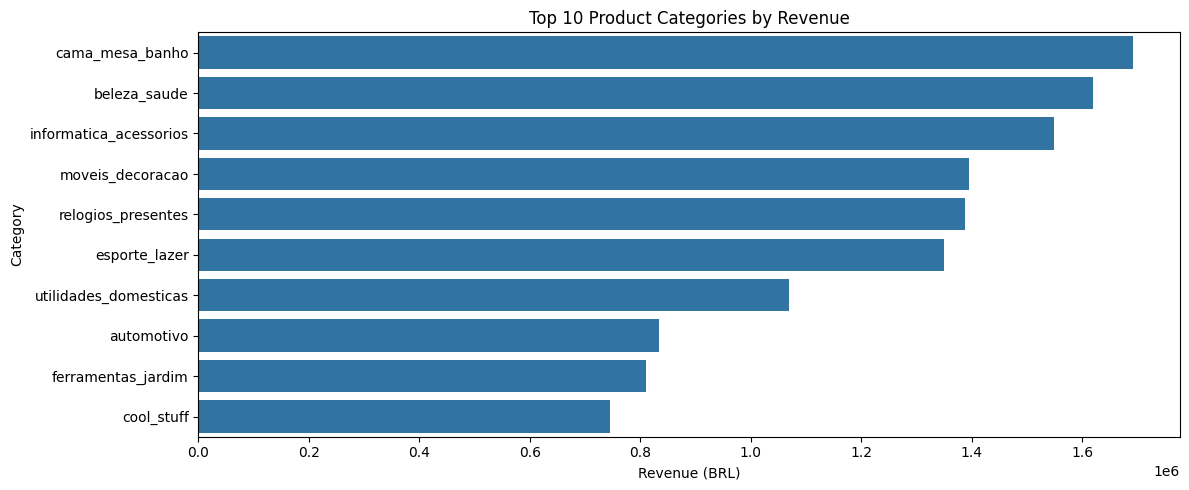

In [11]:
# Mergin products to get category names
df_with_products = df.merge(products[['product_id', 'product_category_name']], 
                             on='product_id', 
                             how='left')

category_revenue = df_with_products.groupby('product_category_name')['payment_value'] \
                                    .sum() \
                                    .sort_values(ascending=False) \
                                    .head(10) \
                                    .reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=category_revenue, x='payment_value', y='product_category_name')
plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Revenue (BRL)')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('charts/top_categories.png', dpi=150)
plt.show()

✅ Step 8: Upload data to BigQuery

Idea:

    Move Cleaned data to a cloud data warehouse


In [12]:
# Save cleaned merged dataframe
df.to_csv('data/olist_clean.csv', index=False)
df_with_products.to_csv('data/olist_with_products.csv', index=False)


This step includes making a BigQuery project that we named **olist-analysis-493517** which has a dataset called **ecommerce**. 

Inside this dataset, we created two tables, **orders_main** and **orders_products**, from the files **olist_clean.csv** and **olist_with_products.csv**, respectively.

✅ Step 9: SQL Analysis in BigQuery

Idea:

    Use SQL to query and analyze data

**Each Query in this step is followed by a Markdown cell explaining it, then a Code cell that loads the CSV results, then the actual SQL code.**

**Note**: Queries were executed in Google BigQuery.

The dataset is not publicly accessible, so results are provided as exported CSV files.


##### Query 1 ~ Monthly Revenue

Aggregated total revenue and order count per month to identify growth trends and seasonality.

In [13]:
monthly_sql = pd.read_csv('data/query1_monthly_revenue.csv')
print(monthly_sql.head())

     month  total_revenue  total_orders
0  2016-09            NaN             1
1  2016-10       61746.94           265
2  2016-12          19.62             1
3  2017-01      176491.49           750
4  2017-02      325782.66          1653


```sql
SELECT
  FORMAT_TIMESTAMP('%Y-%m', TIMESTAMP(order_purchase_timestamp)) AS month,
  ROUND(SUM(payment_value), 2) AS total_revenue,
  COUNT(DISTINCT order_id) AS total_orders
FROM `olist-analysis.ecommerce.orders_main`
GROUP BY month
ORDER BY month
```

##### Query 2 ~ Late Delivery Rate by State

Calculated late delivery rate per state to identify logistics bottlenecks.

**Finding:** AL (Alagoas) has the highest late delivery rate in Brazil.

In [14]:
late_sql = pd.read_csv('data/query2_late_by_state.csv')
print(late_sql.head(10))

  customer_state  total_orders  late_orders  late_rate_pct  avg_delivery_days
0             AL           441          108           24.5               24.1
1             MA           818          166           20.3               21.3
2             PI           553           88           15.9               18.9
3             SE           386           61           15.8               20.9
4             CE          1499          225           15.0               20.4
5             BA          3930          539           13.7               18.7
6             RJ         14873         1925           12.9               14.8
7             PA          1090          135           12.4               23.3
8             ES          2307          280           12.1               15.2
9             RN           561           65           11.6               19.2


```sql
SELECT
  customer_state,
  COUNT(*) AS total_orders,
  SUM(is_late) AS late_orders,
  ROUND(SUM(is_late) / COUNT(*) * 100, 1) AS late_rate_pct,
  ROUND(AVG(delivery_days), 1) AS avg_delivery_days
FROM `olist-analysis.ecommerce.orders_main`
GROUP BY customer_state
ORDER BY late_rate_pct DESC
```

##### Query 3 ~ Top Categories by Revenue
Ranked product categories by total revenue, order volume, and average order value.

**Finding:** Bed, Bath & Table (cama_mesa_banho) is the #1 revenue category.

In [15]:
categories_sql = pd.read_csv('data/query3_top_categories.csv')
print(categories_sql.head(10))

    product_category_name  total_revenue  total_orders  avg_order_value
0         cama_mesa_banho     1692714.28          9272           145.30
1            beleza_saude     1620684.04          8647           166.07
2  informatica_acessorios     1549372.59          6530           196.17
3        moveis_decoracao     1394466.93          6307           162.96
4      relogios_presentes     1387362.45          5495           228.75
5           esporte_lazer     1349446.93          7530           154.52
6   utilidades_domesticas     1069787.97          5743           149.16
7              automotivo      833745.67          3810           194.62
8      ferramentas_jardim      810614.93          3448           181.59
9              cool_stuff      744649.32          3559           190.59


```sql
SELECT
  product_category_name,
  ROUND(SUM(payment_value), 2) AS total_revenue,
  COUNT(DISTINCT order_id) AS total_orders,
  ROUND(AVG(payment_value), 2) AS avg_order_value
FROM `olist-analysis.ecommerce.orders_products`
WHERE product_category_name IS NOT NULL
GROUP BY product_category_name
ORDER BY total_revenue DESC
LIMIT 10
```

##### Query 4 ~ High Value Customers by State
Identified states with highest average spend per order for targeting premium customers.

In [16]:
customers_sql = pd.read_csv('data/query4_high_value_customers.csv')
print(customers_sql.head(10))

  customer_state  total_customers  total_revenue  avg_spend_per_order
0             PB              517      177370.59               284.70
1             AC               80       24890.49               264.79
2             AP               67       21521.71               259.30
3             AL              397      108425.07               245.86
4             RR               41       11300.88               245.67
5             PI              476      133647.81               241.68
6             MA              717      195078.63               238.48
7             PA              946      254824.98               233.78
8             MT              886      251504.48               233.09
9             RO              243       65200.66               232.03


```sql
SELECT
  customer_state,
  COUNT(DISTINCT customer_id) AS total_customers,
  ROUND(SUM(payment_value), 2) AS total_revenue,
  ROUND(AVG(payment_value), 2) AS avg_spend_per_order
FROM `olist-analysis.ecommerce.orders_main`
GROUP BY customer_state
ORDER BY avg_spend_per_order DESC
LIMIT 10
```